# 機械学習の基本コンセプト① 予測

## 分類
データから正解のラベルを予測する方法

### 分類の準備
- データの用意
- 正解データと入力データの準備
- 特徴量作成
 - 単純に予測に利用する列を選択することから、何等かの加工を行って扱いやすい形に変換する
- トレーニングデータとテストデータの準備

In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [4]:
X_raw = iris.data
y = iris.target

In [3]:
X = X_raw[:,[2,3]]
X

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

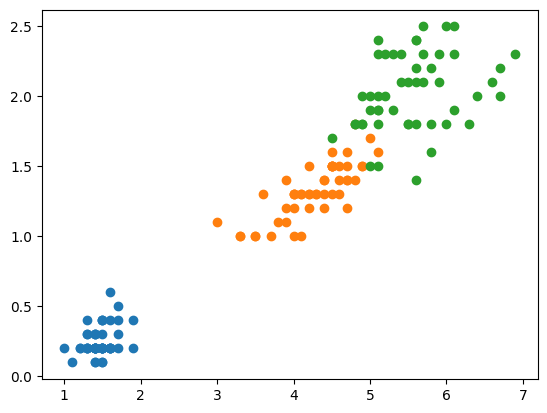

In [8]:
for index, y_class in enumerate(np.unique(y)):
  plt.scatter(X[y == y_class, 0],X[y == y_class, 1])
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [11]:
print('X:', X.shape)
print("X_train:%s, X_test:%s, y_train:%s, y_test:%s" % (X_train.shape, X_test.shape, y_train.shape, y_test.shape))

X: (150, 2)
X_train:(105, 2), X_test:(45, 2), y_train:(105,), y_test:(45,)


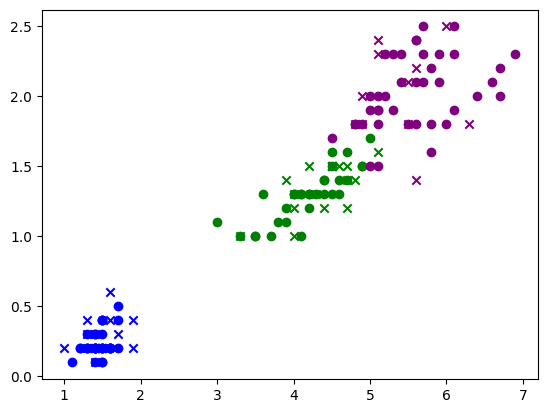

In [12]:
color_map = ['blue', 'green', 'purple']
for  y_class in np.unique(y):
  plt.scatter(X_train[y_train == y_class, 0],X_train[y_train == y_class, 1], c=color_map[y_class])
  plt.scatter(X_test[y_test == y_class, 0],X_test[y_test == y_class, 1], c=color_map[y_class], marker='x')
plt.show()

In [13]:
from sklearn import svm
classifier = svm.SVC()
classifier.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
y_prediction = classifier.predict(X_test)
y_prediction

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0])

In [15]:
from sklearn.metrics import accuracy_score
print('正解率', accuracy_score(y_test, y_prediction))

正解率 0.9777777777777777


## 回帰

In [16]:
from sklearn.datasets import load_boston
boston = load_boston()
boston_df = pd.DataFrame(boston.data, columns=boston.feature_names)
boston_df['MEDV'] = boston.target

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

data null

In [ ]:
choiced_cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'MEDV']
sns.pairplot(boston_df[choiced_cols])

In [ ]:
selected_features = ['RM', 'LSTAT']
X= boston_df[selected_features].values
y= boston_df['MEDV']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_test.shape

In [ ]:
from sklearn import linear_model
cls = linear_model.SGDRegressor(max_iter=1000, tol=1e-3)
cls.fit(X_train, y_train)

In [ ]:
y_prediction = cls.predict(X_test)
y_prediction[:10]

In [ ]:
from sklearn.metrics import mean_squared_error
print('平均二乗誤差(all correct)', mean_squared_error(y_train, y_train))
print('平均二乗誤差(test_data)', mean_squared_error(y_test, y_prediction))

In [ ]:
np.sqrt(40.83)

In [ ]:
plt.scatter(y_test, y_prediction)